In [1]:
!pip -q install h5py numpy scikit-learn matplotlib tensorflow
import os, h5py, numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import tensorflow as tf
print("TF version:", tf.__version__)
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(SEED)
np.random.seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 871.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.2/225.2 kB 20.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


TF version: 2.20.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/ADC2021-examplecode-main"  # change if your folder name is different
!ls -lh "$DATA_DIR"

Mounted at /content/drive
total 3.8G
-rw------- 1 root root 1.1K Jan 27 09:56 00_check_files.py
-rw------- 1 root root 2.6K Jan 27 09:58 01_train_dense.py
-rw------- 1 root root 2.1K Jan 27 10:05 01_train_dense_sklearn.py
-rw------- 1 root root 4.2K Jan 27 11:34 02_eval_signal_and_blackbox.py
-rw------- 1 root root 5.2M Jan 29 09:27 Ato4l_lepFilter_13TeV.h5
-rw------- 1 root root 138M Jan 27 08:25 background_for_training.h5
-rw------- 1 root root 1.7G Jan 27 09:30 BKG_dataset.h5
-rw------- 1 root root 391K Jan 27 11:34 bkg_mse.npy
-rw------- 1 root root 152M Jan 25 19:59 BlackBox_13TeV_PU20.h5
-rw------- 1 root root  48M Jan 27 05:32 BlackBox_background_mix.h5
-rw------- 1 root root  11K Jan 27 07:47 computeFLOPs.ipynb
-rw------- 1 root root  11K Jan 27 07:47 Convolutional_AE.ipynb
-rw------- 1 root root 3.4K Jan 27 07:47 create_datasets.py
-rw------- 1 root root  11K Jan 27 07:47 Dense_AE.ipynb
-rw------- 1 root root  42K Jan 27 11:12 dense_ae_sklearn.joblib
-rw------- 1 root root 1.6

In [3]:
def inspect_h5(path):
    print("\nFILE:", os.path.basename(path))
    with h5py.File(path, "r") as f:
        print("Keys:", list(f.keys()))
        for k in f.keys():
            try:
                print(" ", k, f[k].shape, f[k].dtype)
            except:
                print(" ", k, "no shape")

inspect_h5(os.path.join(DATA_DIR, "BlackBox_13TeV_PU20.h5"))



FILE: BlackBox_13TeV_PU20.h5
Keys: ['EvtId', 'Particles', 'Particles_Classes', 'Particles_Names']
  EvtId (4210492,) int64
  Particles (4210492, 19, 4) float64
  Particles_Classes (4,) |S16
  Particles_Names (4,) |S5


In [4]:
inspect_h5(os.path.join(DATA_DIR, "BKG_dataset.h5"))


FILE: BKG_dataset.h5
Keys: ['X_test', 'X_train', 'X_val']
  X_test (800000, 57) float64
  X_train (2560000, 57) float64
  X_val (640000, 57) float64


In [5]:
def load_bkg_splits(path):
    with h5py.File(path, "r") as f:
        X_train = np.array(f["X_train"])
        X_val   = np.array(f["X_val"])
        X_test  = np.array(f["X_test"])
    return X_train, X_val, X_test

X_train, X_val, X_test = load_bkg_splits(os.path.join(DATA_DIR, "BKG_dataset.h5"))
print(X_train.shape, X_val.shape, X_test.shape)


(2560000, 57) (640000, 57) (800000, 57)


In [6]:
def preprocess(X):
    X = X.astype("float32").copy()

    # Keep only first 3 features (pT, eta, phi)
    # This matches the common AE setup and gives 19*3 = 57 features
    if X.shape[-1] == 4:
        X = X[:, :, :3]

    # Optional: log scale pT (feature 0)
    X[..., 0] = np.log1p(np.maximum(X[..., 0], 0))

    # Flatten to (N, 57)
    return X.reshape(X.shape[0], -1)


X_train_f = preprocess(X_train)
X_val_f   = preprocess(X_val)
X_test_f  = preprocess(X_test)

mean = X_train_f.mean(axis=0, keepdims=True)
std  = X_train_f.std(axis=0, keepdims=True) + 1e-6

X_train_n = (X_train_f - mean) / std
X_val_n   = (X_val_f   - mean) / std
X_test_n  = (X_test_f  - mean) / std

print("Final input shape:", X_train_n.shape)

Final input shape: (2560000, 57)


In [48]:
len(X_test_n), len(X_val_n)

(800000, 640000)

In [8]:
X_combined = np.concatenate([X_train_n, X_test_n], axis=0)
print("Shape of combined array:", X_combined.shape)

Shape of combined array: (3360000, 57)


In [47]:
X_train_n[1]

array([ 6.5222484e-01,  0.0000000e+00,  1.1934361e+00, -9.5146865e-01,
       -2.4449205e-06, -8.8618085e-04, -3.5905603e-02,  4.0544366e-04,
       -5.5763416e-04, -1.0729650e-02,  3.2694521e-04, -1.4270452e-04,
       -2.6231003e-03, -3.6225011e-04,  2.3725601e-04,  1.1461171e+00,
        1.4137462e+00, -1.6669813e+00, -3.0238340e-02,  5.4205273e-04,
        8.4854619e-05, -7.9384986e-03,  4.7600763e-05,  6.6098664e-04,
       -1.9082292e-03, -3.2285761e-04, -6.5318088e-04,  6.5906268e-01,
       -1.9328737e+00,  4.1643131e-01,  2.1534224e+00, -6.2294662e-01,
       -4.0196114e+00,  3.8958569e+00,  9.3224287e-01, -2.9864478e+00,
       -8.7568201e-02,  5.9203459e-05,  1.6587993e-04, -5.7254780e-02,
        3.1205421e-04,  1.9207571e-04, -3.9750505e-02,  6.9560687e-04,
       -3.8065125e-05, -2.7337415e-02,  7.6727942e-04, -1.0464353e-04,
       -1.7977441e-02, -5.2492158e-04,  5.6200433e-06, -1.1271842e-02,
       -6.3457678e-04,  1.3710512e-03, -7.1714344e-03,  4.6926123e-04,
      

In [10]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers # Import regularizers

In [11]:

from tensorflow.keras.callbacks import ReduceLROnPlateau

# Reduce learning rate when validation loss is plateauing
lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)

# Example of skip connections in the model
inp = keras.Input(shape=(X_train_n.shape[1],))

x = layers.Dense(256, activation="relu")(inp)
x = layers.Dropout(0.3)(x)  # Add dropout layer
x = layers.Dense(128, activation="relu")(x)
# skip = x  # Save the intermediate result for skip connection
x = layers.Dense(64, activation="relu")(x)

# To make shapes compatible for skip connection, add a Dense layer to 'skip'
# that matches the dimension of 'x' before the Add layer.
# skip_processed = layers.Dense(64, activation="relu")(x)

# Skip connection to bypass some layers
# x = layers.Add()([x, skip_processed])  # Adding skip connection
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(256, activation="relu")(x)
out = layers.Dense(X_train_n.shape[1], activation=None)(x)

ae = keras.Model(inp, out)
ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")

In [12]:
history = ae.fit(
    X_combined, X_combined,
    validation_data=(X_val_n, X_val_n),
    callbacks=[lr_scheduler],
    epochs=50,
    batch_size=2048
)

Epoch 1/50
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 32s 18ms/step - loss: 0.4665 - val_loss: 0.2561 - learning_rate: 0.0010
Epoch 2/50
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - loss: 0.2059 - val_loss: 0.1912 - learning_rate: 0.0010
Epoch 3/50
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - loss: 0.1748 - val_loss: 0.2158 - learning_rate: 0.0010
Epoch 4/50
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - loss: 0.1568 - val_loss: 0.1708 - learning_rate: 0.0010
Epoch 5/50
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - loss: 0.1574 - val_loss: 0.1748 - learning_rate: 0.0010
Epoch 6/50
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - loss: 0.1404 - val_loss: 0.1514 - learning_rate: 0.0010
Epoch 7/50
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - loss: 0.1467 - val_loss: 0.1619 - learning_rate: 0.0010
Epoch 8/50
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - loss: 0.1398 - val_loss: 0.1605 - learning_rate: 0.0010
Epoch 9/50
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - loss: 0.1129 - val_loss: 0.086

In [13]:
def anomaly_score(model, Xn, batch_size=2048):
    Xhat = model.predict(Xn, batch_size=batch_size, verbose=0)
    mse = np.mean((Xn - Xhat)**2, axis=1)
    return mse

bkg_scores = anomaly_score(ae, X_test_n)
print("Background scores:", bkg_scores.min(), bkg_scores.mean(), bkg_scores.max())

Background scores: 2.2199405e-05 0.018628767 325.1223


In [14]:
def load_particles(path, max_events=None):
    with h5py.File(path, "r") as f:
        X = f["Particles"][:max_events] if max_events else f["Particles"][:]
    return X


In [15]:
print("mean shape:", mean.shape)
print("std shape:", std.shape)
print("bkg_scores shape:", bkg_scores.shape)

mean shape: (1, 57)
std shape: (1, 57)
bkg_scores shape: (800000,)


In [16]:
signal_files = [
    "Ato4l_lepFilter_13TeV.h5",
    "hToTauTau_13TeV_PU20.h5",
    "hChToTauNu_13TeV_PU20.h5",
    "leptoquark_LOWMASS_lepFilter_13TeV.h5",
]

for sf in signal_files:
    spath = os.path.join(DATA_DIR, sf)
    if not os.path.exists(spath):
        print("Missing:", sf)
        continue

    X_sig = preprocess(load_particles(spath))
    X_sig_n = (X_sig - mean) / std

    sig_scores = anomaly_score(ae, X_sig_n)

    y = np.concatenate([np.zeros_like(bkg_scores), np.ones_like(sig_scores)])
    s = np.concatenate([bkg_scores, sig_scores])

    auc = roc_auc_score(y, s)
    print(f"{sf:40s}  ROC-AUC = {auc:.4f}")


Ato4l_lepFilter_13TeV.h5                  ROC-AUC = 0.9929
hToTauTau_13TeV_PU20.h5                   ROC-AUC = 0.9788
hChToTauNu_13TeV_PU20.h5                  ROC-AUC = 0.9878
leptoquark_LOWMASS_lepFilter_13TeV.h5     ROC-AUC = 0.9872


In [17]:
bb_path = os.path.join(DATA_DIR, "BlackBox_13TeV_PU20.h5")

with h5py.File(bb_path, "r") as f:
    X_bb = f["Particles"][:]
    evtid = f["EvtId"][:]

X_bb_f = preprocess(X_bb)
X_bb_n = (X_bb_f - mean) / std

bb_scores = anomaly_score(ae, X_bb_n)

In [18]:
# Set threshold at 99th percentile of background scores
# threshold = np.percentile(bb_scores, 90)

# To predict top 1% anomalies in background
threshold = np.percentile(bkg_scores, 99)  # 99th percentile for background

# Set the threshold for signal dataset (usually lower)
sig_threshold = np.min(sig_scores)  # Lower than background threshold, to capture all signal anomalies

In [19]:
# Flag anomalies in the background, signal, and blackbox datasets
anomalies_bkg = bkg_scores > 0.09013264
anomalies_sig = sig_scores > 0.09013264
anomalies_blackbox = bb_scores > 0.09013264

In [22]:
threshold   # signal minimun threshold np.float32(0.10008817)

np.float32(0.10590055)

In [23]:
sig_threshold - threshold

np.float32(-0.10394698)

In [24]:
anomalies_bkg = anomalies_bkg.astype(int)
anomalies_sig = anomalies_sig.astype(int)
anomalies_blackbox = anomalies_blackbox.astype(int)

In [25]:
'Signal Total Events :',len(anomalies_sig),' Background Total Events :', len(anomalies_bkg),' Blackbox Total Events :' , len(anomalies_blackbox)

('Signal Total Events :',
 340544,
 ' Background Total Events :',
 800000,
 ' Blackbox Total Events :',
 4210492)

In [26]:
print("Background anomalies:", anomalies_bkg.sum())
print("Signal anomalies:", anomalies_sig.sum())
print("BlackBox anomalies:", anomalies_blackbox.sum())

Background anomalies: 8801
Signal anomalies: 201361
BlackBox anomalies: 101191


In [27]:
print("Background anomalies:", anomalies_bkg.sum())
print("Signal anomalies:", anomalies_sig.sum())
print("BlackBox anomalies:", anomalies_blackbox.sum())

Background anomalies: 8801
Signal anomalies: 201361
BlackBox anomalies: 101191


In [28]:

topk = 1000
idx = np.argsort(-bb_scores)[:topk]  # descending
top_evtid = evtid[idx]
top_scores = bb_scores[idx]

out_path = "/content/adc2021_top1000.csv"
import pandas as pd
pd.DataFrame({"EvtId": top_evtid, "score": top_scores}).to_csv(out_path, index=False)

print("Saved:", out_path)
print("First 10 IDs:", top_evtid[:10])

Saved: /content/adc2021_top1000.csv
First 10 IDs: [3447383 2933923 1222540 2613060 1712357 3487455 3442864  274417 2782469
 1610786]


In [ ]:
# Anomaly score calculation: Mean Squared Error (MSE) between input and reconstruction
def anomaly_score(model, Xn):
    Xhat = model.predict(Xn, batch_size=4096, verbose=0)
    mse = np.mean((Xn - Xhat)**2, axis=1)
    return mse

# For background (normal) and signal (anomalous) datasets
bkg_scores = anomaly_score(ae, X_test_n)  # Background anomaly scores
sig_scores = anomaly_score(ae, X_sig_n)  # Signal anomaly scores

In [ ]:
'background anomaly scores', 'mean: ', bkg_scores.mean(), 'max', bkg_scores.max(),'min', bkg_scores.min()

('background anomaly scores',
 'mean: ',
 np.float32(0.06552155),
 'max',
 np.float32(8799.588),
 'min',
 np.float32(0.0010068659))

In [ ]:
'Signal anomaly scores', 'mean: ', sig_scores.mean(),'max', sig_scores.max(),'min', sig_scores.min()

('Signal anomaly scores',
 'mean: ',
 np.float32(8.730728),
 'max',
 np.float32(19360.943),
 'min',
 np.float32(0.011606858))

In [30]:
# Combine the anomaly scores from background and signal
y_true = np.concatenate([np.zeros_like(bkg_scores), np.ones_like(sig_scores)])  # True labels (0 for background, 1 for signal)
scores = np.concatenate([bkg_scores, sig_scores])  # Combined anomaly scores

In [31]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

def tpr_at_fpr(fpr, tpr, target_fpr=1e-4):
    idx = (fpr <= target_fpr).nonzero()[0]
    if len(idx) == 0:
        return 0.0
    return tpr[idx[-1]]

for target_fpr in [1e-3, 1e-4, 1e-5]:
    print(f"TPR at FPR={target_fpr}: {tpr_at_fpr(fpr, tpr, target_fpr)}")


TPR at FPR=0.001: 0.09423158240932156
TPR at FPR=0.0001: 0.009857757000563804
TPR at FPR=1e-05: 0.002451959218192069


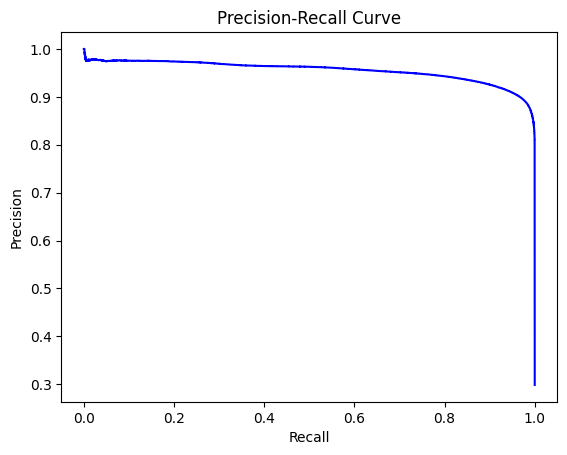

AUC-PR: 0.9553517781456913


In [32]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_true, scores)
auc_pr = average_precision_score(y_true, scores)

# Plot PR curve
plt.plot(recall, precision, color='b', label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

print(f"AUC-PR: {auc_pr}")

In [33]:
import numpy as np
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, scores)

prec_aligned = precision[:-1]
rec_aligned = recall[:-1]
f1_scores = 2 * (prec_aligned * rec_aligned) / (prec_aligned + rec_aligned + np.finfo(float).eps)

optimal_threshold_idx = np.argmax(f1_scores)
print(f"Debug: Optimal threshold index (argmax result): {optimal_threshold_idx}")

if optimal_threshold_idx >= len(thresholds):
    print(f"Warning: optimal_threshold_idx ({optimal_threshold_idx}) is out of bounds for thresholds (size {len(thresholds)}). Adjusting index.")
    optimal_threshold_idx = len(thresholds) - 1 # Fallback to the last valid index

optimal_threshold = thresholds[optimal_threshold_idx]
print(f"Optimal Threshold: {optimal_threshold}")

y_pred = (scores >= optimal_threshold).astype(int)

print("TPR at FPR 0.001:", tpr_at_fpr(fpr, tpr, 0.001))

Debug: Optimal threshold index (argmax result): 760219
Optimal Threshold: 0.00685768062248826
TPR at FPR 0.001: 0.09423158240932156


In [36]:
from sklearn.ensemble import IsolationForest

# Create an encoder model to get the latent space representation
encoder = keras.Model(inputs=ae.input, outputs=ae.layers[5].output)

# We fit IsolationForest on the training data's latent space to learn the 'normal' distribution.
latent_train_rep = encoder.predict(X_combined, batch_size=512)

iso_forest = IsolationForest(contamination=0.001, random_state=SEED, n_jobs=-1)
iso_forest.fit(latent_train_rep)

latent_test_rep = encoder.predict(X_test_n, batch_size=2048)
anomalies_test = iso_forest.predict(latent_test_rep)

print("Anomalies detected in test set (-1 indicates anomaly):", sum(anomalies_test == -1))

latent_sig_rep = encoder.predict(X_sig_n, batch_size=2048)
anomalies_sig = iso_forest.predict(latent_sig_rep)
print("Anomalies detected in signal set (-1 indicates anomaly):", sum(anomalies_sig == -1))


6563/6563 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Anomalies detected in test set (-1 indicates anomaly): 817
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Anomalies detected in signal set (-1 indicates anomaly): 1334


<Axes: >

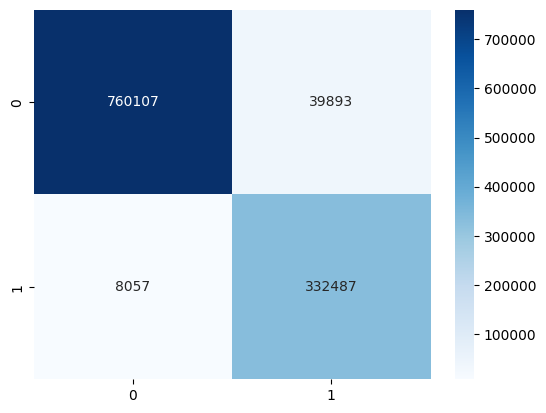

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = (scores >= optimal_threshold).astype(int)

conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")

In [37]:
# For a given target FPR on background only:
target_fpr = 0.01  # 1%
thr = np.quantile(bkg_scores, 1 - target_fpr)

fpr = np.mean(bkg_scores > thr)
tpr = np.mean(sig_scores > thr)

print("FPR on background:", fpr)
print("TPR on signal:", tpr)

FPR on background: 0.01
TPR on signal: 0.5631812629205036


In [40]:
K = 1000
idx_sorted = np.argsort(bb_scores)
topk_idx = idx_sorted[-K:]
topk_thr  = bb_scores[topk_idx[0]]  # smallest score among top K

In [45]:
print("Smallest Among All Top K: ", topk_thr)

Smallest Among All Top K:  27.185774


In [52]:
print('First 50 Score of Top 1000 K Events')
topk_idx[:50]

First 50 Score of Top 1000 K Events


array([3237911, 2335878, 3070816, 3749540, 3011339, 1484125, 3777611,
        892696,  928734, 1261666,  527178, 3039129,  837690, 2262271,
       2676444, 2118568,   32783, 2586567, 2576432, 2683072,  431388,
       1912286, 3450195,  910986, 2789235,   14146, 3274428, 1310932,
       1635122, 1470143,  842049, 1683542,  167854,  692950, 1355929,
        241399, 1728144, 1848834, 2682329, 2316664, 2792967, 2854318,
       1938120, 3497044, 1915691,  882420, 2227660, 3043180, 2775661,
       1861744])

In [53]:
frac = 0.02
thr_bb = np.quantile(bb_scores, 1 - frac)

anom_bb_mask = bb_scores > thr_bb
print("Fraction anomalies in blackbox:", anom_bb_mask.mean())

Fraction anomalies in blackbox: 0.0200000380003097
